# Torch Batteries Example: Iris Classification with DataPack

This notebook focuses on `DataPack`, the event-driven data configuration in torch-batteries. It downloads the scikit-learn Iris dataset from the Hugging Face Hub, creates deterministic stratified splits, configures DataLoaders by phase, and trains a tiny MLP with implicit loaders.

[DataPack guide](https://michalszc.github.io/torch-batteries/guides/data-pack/) · [Training guide](https://michalszc.github.io/torch-batteries/guides/training/) · [Events API](https://michalszc.github.io/torch-batteries/reference/events/)

## 0. Prerequisites

Use Python 3.12 or newer. The installation cell includes the `example` dependencies, including Hugging Face Datasets and scikit-learn. Restart the kernel if the notebook application asks you to
do so after installation.

The Iris dataset contains four sepal and petal measurements for three balanced flower species. Its initial download is small, and the CPU training run normally takes only a few seconds.

In [ ]:
%pip install "torch-batteries[example]"

## 1. Setup

Import the public torch-batteries contracts and report the installed versions used for this saved run.

In [1]:
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
import torch_batteries
from datasets import load_dataset
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from torch import nn
from torch.nn import functional as F
from torch.utils.data import TensorDataset

from torch_batteries import (
    Battery,
    DataContext,
    DataLoaderConfig,
    DataPack,
    DatasetBundle,
    Event,
    EventContext,
    StepOutput,
    charge,
)

print(f"torch-batteries version: {torch_batteries.__version__}")

torch-batteries version: 0.11.0


## 2. Define the Iris DataPack

The four charged methods divide data responsibilities clearly:

- `PREPARE_DATA` downloads or opens the cached Hugging Face dataset and prepares deterministic split indices once per Battery.
- `SETUP_DATA` uses the active stage to create only fit, test, or prediction datasets for each workflow.
- `CONFIGURE_DATALOADER` returns high-level loader instructions for every requested phase. Training shuffles automatically; the other phases do not.
- `TEARDOWN_DATA` records cleanup after every implicit workflow, including failures.

The split indices are part of the DataPack checkpoint state. Normalization statistics are calculated from the training split only, preventing validation/test leakage. The identifier column is deliberately excluded.

In [2]:
class IrisDataPack(DataPack):
    seed = 17
    feature_names = (
        "SepalLengthCm",
        "SepalWidthCm",
        "PetalLengthCm",
        "PetalWidthCm",
    )
    class_names = ("Iris-setosa", "Iris-versicolor", "Iris-virginica")

    def __init__(self, batch_size=16):
        self.batch_size = batch_size
        self.raw_dataset = None
        self.split_indices = None
        self.split_sizes = {}
        self.predict_targets = None
        self.teardown_stages = []

    @charge(Event.PREPARE_DATA)
    def prepare(self, context: DataContext):
        self.raw_dataset = load_dataset("scikit-learn/iris")["train"]
        if self.split_indices is None:
            label_lookup = {name: index for index, name in enumerate(self.class_names)}
            targets = np.asarray(
                [label_lookup[name] for name in self.raw_dataset["Species"]],
                dtype=np.int64,
            )
            indices = np.arange(len(targets))
            train_validation, test = train_test_split(
                indices, test_size=0.20, random_state=context["seed"], stratify=targets
            )
            train, validation = train_test_split(
                train_validation,
                test_size=0.25,
                random_state=context["seed"],
                stratify=targets[train_validation],
            )
            self.split_indices = {
                "train": train.tolist(),
                "validation": validation.tolist(),
                "test": test.tolist(),
            }
        self.split_sizes = {
            name: len(indices) for name, indices in self.split_indices.items()
        }

    @charge(Event.SETUP_DATA)
    def setup(self, context: DataContext):
        features = np.column_stack(
            [np.asarray(self.raw_dataset[name], dtype=np.float32) for name in self.feature_names]
        )
        label_lookup = {name: index for index, name in enumerate(self.class_names)}
        targets = np.asarray(
            [label_lookup[name] for name in self.raw_dataset["Species"]], dtype=np.int64
        )
        mean = features[self.split_indices["train"]].mean(axis=0, keepdims=True)
        std = features[self.split_indices["train"]].std(axis=0, keepdims=True)

        def tensor_dataset(rows):
            return TensorDataset(
                torch.from_numpy((features[rows] - mean) / std),
                torch.from_numpy(targets[rows]),
            )

        if context["stage"] == "fit":
            return DatasetBundle(
                train=tensor_dataset(self.split_indices["train"]),
                validation=tensor_dataset(self.split_indices["validation"]),
            )
        if context["stage"] == "test":
            return DatasetBundle(test=tensor_dataset(self.split_indices["test"]))

        self.predict_targets = torch.from_numpy(targets[self.split_indices["test"]])
        return DatasetBundle(predict=tensor_dataset(self.split_indices["test"]))

    def state_dict(self):
        return {"split_indices": self.split_indices}

    def load_state_dict(self, state_dict):
        self.split_indices = state_dict["split_indices"]

    @charge(Event.CONFIGURE_DATALOADER)
    def configure_loader(self, _context: DataContext):
        return DataLoaderConfig(batch_size=self.batch_size)

    @charge(Event.TEARDOWN_DATA)
    def teardown(self, context: DataContext):
        self.teardown_stages.append(context["stage"])

## 3. Define a Tiny MLP

The model remains responsible only for task behavior. One shared supervised helper keeps the charged train, validation, and test steps consistent. `StepOutput` exposes logits and labels so Battery can calculate accuracy without another forward pass.

In [3]:
class IrisMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 3),
        )

    def forward(self, features):
        return self.network(features)

    def supervised_step(self, context: EventContext):
        features, targets = context["batch"]
        logits = self(features)
        return StepOutput(
            loss=F.cross_entropy(logits, targets),
            predictions=logits,
            targets=targets,
        )

    @charge(Event.TRAIN_STEP)
    def train_step(self, context: EventContext):
        return self.supervised_step(context)

    @charge(Event.VALIDATION_STEP)
    def validation_step(self, context: EventContext):
        return self.supervised_step(context)

    @charge(Event.TEST_STEP)
    def test_step(self, context: EventContext):
        return self.supervised_step(context)

    @charge(Event.PREDICT_STEP)
    def predict_step(self, context: EventContext):
        features, _ = context["batch"]
        return self(features).argmax(dim=1)


def accuracy(logits, targets):
    return (logits.argmax(dim=1) == targets).float().mean()

## 4. Train without Passing DataLoaders

Attach the DataPack to `Battery`, then omit `train_loader` and `val_loader`. Battery prepares the data once, calls setup for the fit workflow, constructs fresh phase loaders, and guarantees teardown afterward.

With only 90 training rows and a 16-unit hidden layer, 50 epochs remain comfortably below the two-minute target on CPU.

In [4]:
torch.manual_seed(17)
data_pack = IrisDataPack(batch_size=16)
model = IrisMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
battery = Battery(
    model,
    device="cpu",
    optimizer=optimizer,
    metrics={"accuracy": accuracy},
    data_pack=data_pack,
)

started = perf_counter()
history = battery.fit(epochs=50, verbose=0)
training_seconds = perf_counter() - started

In [5]:
print(f"Split sizes: {data_pack.split_sizes}")
print(f"Training time: {training_seconds:.2f} seconds")
print(f"Final train accuracy: {history['train_metrics']['accuracy'][-1]:.1%}")
print(f"Final validation accuracy: {history['val_metrics']['accuracy'][-1]:.1%}")
print(f"Completed DataPack stages: {data_pack.teardown_stages}")

Split sizes: {'train': 90, 'validation': 30, 'test': 30}
Training time: 2.14 seconds
Final train accuracy: 100.0%
Final validation accuracy: 93.3%
Completed DataPack stages: ['fit']


## 5. Evaluate with an Implicit Test Loader

Calling `test()` without arguments starts a separate DataPack workflow. Preparation is not repeated, but setup and teardown run again. The fixed seed recreates the same held-out split.

In [6]:
test_result = battery.test(verbose=0)
test_accuracy = test_result["test_metrics"]["accuracy"]
print(f"Test loss: {test_result['test_loss']:.4f}")
print(f"Test accuracy: {test_accuracy:.1%}")
print(f"Completed DataPack stages: {data_pack.teardown_stages}")

Test loss: 0.0620
Test accuracy: 96.7%
Completed DataPack stages: ['fit', 'test']


## 6. Predict and Inspect the Confusion Matrix

The prediction dataset is the held-out test split. `concatenate=True` combines the phase's batch outputs into one tensor, and `move_to_cpu=True` makes it ready for scikit-learn inspection.

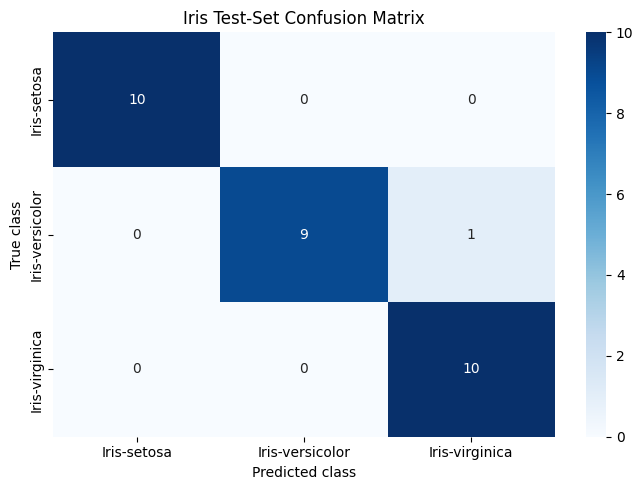

Completed DataPack stages: ['fit', 'test', 'predict']


In [7]:
prediction_result = battery.predict(
    verbose=0, move_to_cpu=True, concatenate=True
)
predictions = prediction_result["predictions"]
matrix = confusion_matrix(data_pack.predict_targets.numpy(), predictions.numpy())

plt.figure(figsize=(7, 5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data_pack.class_names,
    yticklabels=data_pack.class_names,
)
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("Iris Test-Set Confusion Matrix")
plt.tight_layout()
plt.show()
print(f"Completed DataPack stages: {data_pack.teardown_stages}")